In [1]:
# Import library dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Agar plot tampil rapi
plt.rcParams['figure.figsize'] = (8, 6)


In [2]:
# Load dataset Wine
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Tampilkan 5 baris pertama
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

np.int64(0)

In [4]:
# Distribusi kelas target
print("Nama kelas:", wine.target_names)
df['target'].value_counts()


Nama kelas: ['class_0' 'class_1' 'class_2']


,count
target,
1,71
0,59
2,48


In [5]:
# Fitur dan Label
X = wine.data
y = wine.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (178, 13)
Shape y: (178,)


In [6]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test", X_test.shape)


Shape X_train: (142, 13)
Shape X_test (36, 13)


In [7]:
# Standarisasi data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]


array([[ 0.38580089, -0.63787118,  1.77666817, -1.22453161,  0.69643032,
         0.52686525,  0.73229212, -0.1695489 , -0.41578344, -0.16746725,
         0.62437819,  0.2529082 ,  0.46772474],
       [ 0.94851892, -0.76544542,  1.25317383,  0.85328406,  0.09178497,
         1.17279546,  1.33318146, -0.59045701,  1.34974202,  0.30530313,
         1.06715537,  0.15104809,  1.81576773],
       [ 0.52335419, -0.51940939,  0.9540342 , -1.04643312, -0.44567755,
         0.93057163,  1.006382  , -0.1695489 , -0.26000178, -0.081509  ,
        -0.12834302,  0.89317174,  1.51620262],
       [ 0.97352861, -0.55585917,  0.16879269, -1.0761162 , -0.71440882,
         0.52686525,  0.81662747, -0.59045701,  0.36312485,  0.262324  ,
         0.8900445 ,  0.42752553,  1.93226527],
       [ 0.43582027,  0.82012009,  0.05661533,  0.55645325, -0.51286037,
        -0.55506784, -1.29175618,  0.75644894, -0.60618325,  1.47433535,
        -1.76661859, -1.43505932, -0.29783054]])

In [8]:
# Model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

print("Akurasi SVM tanpa PCA:", accuracy_score(y_test, y_pred_no_pca))
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))


Akurasi SVM tanpa PCA: 0.9722222222222222
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [9]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca", X_test_pca.shape)


Shape X_train_pca: (142, 3)
Shape X_test_pca (36, 3)


In [11]:
# Variansi yang dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
explained_var
print("Total variansi yang dijelaskan 3 komponen pertama:", explained_var.sum())


Total variansi yang dijelaskan 3 komponen pertama: 0.6608261082211259


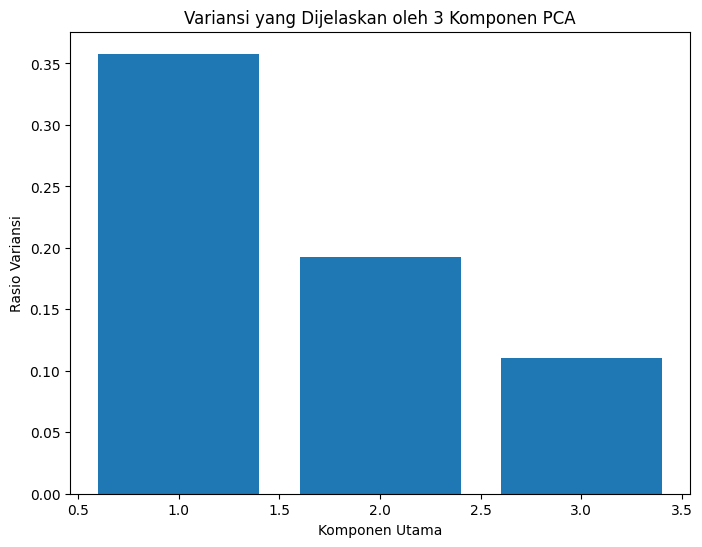

In [12]:
# Visualisasi variansi PCA
plt.bar([1, 2, 3], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Rasio Variansi')
plt.title('Variansi yang Dijelaskan oleh 3 Komponen PCA')
plt.show()


In [13]:
# Model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

print("Akurasi SVM dengan PCA:", accuracy_score(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca, target_names=wine.target_names))


Akurasi SVM dengan PCA: 0.9722222222222222
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



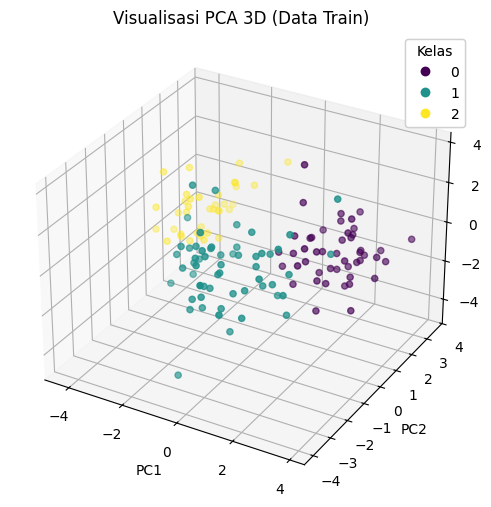

In [14]:
# Visualisasi 3D PCA (menggunakan data train)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    cmap='viridis'
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Visualisasi PCA 3D (Data Train)')

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Kelas"
)
ax.add_artist(legend1)

plt.show()


In [15]:
# Membandingkan hasil model tanpa dan dengan PCA
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA'],
    'Akurasi': [
        accuracy_score(y_test, y_pred_no_pca),
        accuracy_score(y_test, y_pred_pca)
    ],
    'Variansi Total PCA': [None, explained_var.sum()]
})

comparison


,Model,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,0.972222,NaN
1,SVM Dengan PCA,0.972222,0.660826


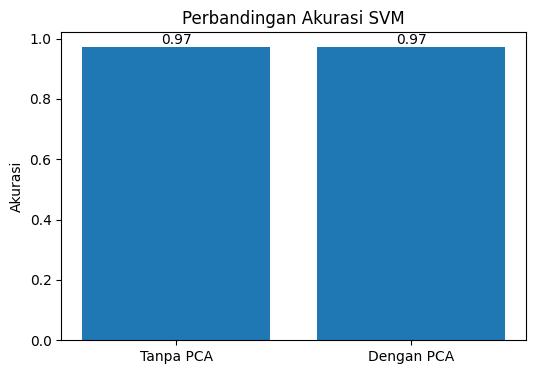

In [17]:
# Visualisasi perbandingan akurasi
plt.figure(figsize=(6,4))
plt.bar(['Tanpa PCA', 'Dengan PCA'], comparison['Akurasi'])

for i, v in enumerate(comparison['Akurasi']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi SVM')
plt.show()



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('data.csv')
df = df.dropna(axis=1)

X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Total Variansi:", explained_variance.sum())

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance PCA')
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=(y == 'M'),
    cmap='coolwarm',
    alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi PCA 2D')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'